In [1]:
using Plots

In [2]:
dt = 0.5
g = 9.82

9.82

In [56]:
mutable struct Pendulum
    mass::Float64
    len::Float64
    θ::Float64
    ω::Float64
end

function α(pen1::Pendulum, pen2::Pendulum, pen3::Pendulum)
    g = 9.81
    m1, m2, m3 = pen1.mass, pen2.mass, pen3.mass
    l1, l2, l3 = pen1.len, pen2.len, pen3.len
    θ1, θ2, θ3 = pen1.θ, pen2.θ, pen3.θ
    ω1, ω2, ω3 = pen1.ω, pen2.ω, pen3.ω

    s1, c1 = sincos(θ1)
    s2, c2 = sincos(θ2)
    s3, c3 = sincos(θ3)
    s12, c12 = sincos(θ1 - θ2)
    s13, c13 = sincos(θ1 - θ3)
    s23, c23 = sincos(θ2 - θ3)

    A = [
        (m1+m2+m3)*l1^2    (m2+m3)*l1*l2*c12    m3*l1*l3*c13;
        (m2+m3)*l1*l2*c12  (m2+m3)*l2^2         m3*l2*l3*c23;
        m3*l1*l3*c13       m3*l2*l3*c23         m3*l3^2
    ]

    b = [
        (m2+m3)*l1*l2*s12*ω2^2 + m3*l1*l3*s13*ω3^2 - (m1+m2+m3)*g*l1*s1;
        -l1*l2*s12*ω1^2 + m3*l2*l3*s23*ω3^2 - (m2+m3)*g*l2*s2;
        -l1*l3*s13*ω1^2 - l2*l3*s23*ω2^2 - m3*g*l3*s3
    ]

    # Solve the system
    α = A \ b

    return α
end

function derivatives(state, pen1::Pendulum, pen2::Pendulum, pen3::Pendulum)
    θ1, ω1, θ2, ω2, θ3, ω3 = state

    dθ1, dθ2, dθ3 = ω1, ω2, ω3
    dω1, dω2, dω3 = α(
        Pendulum(pen1.mass, pen1.len, θ1, ω1),
        Pendulum(pen2.mass, pen2.len, θ2, ω2),
        Pendulum(pen3.mass, pen3.len, θ3, ω3)
    )
    
    return [dθ1, dω1, dθ2, dω2, dθ3, dω3]
end


derivatives (generic function with 1 method)

In [21]:
function RK4(h::Float64, pen1::Pendulum, pen2::Pendulum, pen3::Pendulum)
    state = [pen1.θ, pen1.ω, pen2.θ, pen2.ω, pen3.θ, pen3.ω]
    
    k1 = h * derivatives(state, pen1, pen2, pen3)
    k2 = h * derivatives(state + k1/2, pen1, pen2, pen3)
    k3 = h * derivatives(state + k2/2, pen1, pen2, pen3)
    k4 = h * derivatives(state + k3, pen1, pen2, pen3)
    
    return state + (k1 + 2k2 + 2k3 + k4) / 6
end

function iterate_triple_pendulum(dt::Float64, pen1::Pendulum, pen2::Pendulum, pen3::Pendulum)
    pen1.θ, pen1.ω, pen2.θ, pen2.ω, pen3.θ, pen3.ω = RK4(dt, pen1, pen2, pen3)
end

function calculate_positions(pen1::Pendulum, pen2::Pendulum, pen3::Pendulum)
    x1 = pen1.len * sin(pen1.θ)
    y1 = -pen1.len * cos(pen1.θ)
    x2 = x1 + pen2.len * sin(pen2.θ)
    y2 = y1 - pen2.len * cos(pen2.θ)
    x3 = x2 + pen3.len * sin(pen3.θ) 
    y3 = y2 - pen3.len * cos(pen3.θ)
    return [0, x1, x2, x3], [0, y1, y2, y3]
end

calculate_positions (generic function with 1 method)

[ Info: Saved animation to /Users/05jaco01/Code/Physics/Pendulums/double_pendulum.gif


Plots.AnimatedGif("/Users/05jaco01/Code/Physics/Pendulums/double_pendulum.gif")
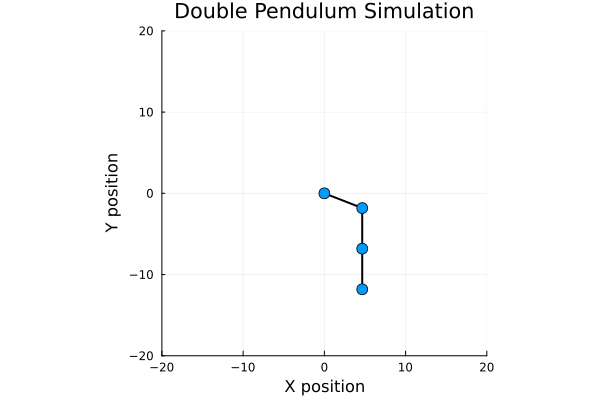

In [55]:
dt = 0.02

pen1 = Pendulum(1, 5, 1.2, 0) 
pen2 = Pendulum(1, 5, 0, 0)
pen3 = Pendulum(5, 5, 0, 0)

anim = @animate for i in 1:300 
    iterate_triple_pendulum(dt, pen1, pen2, pen3)
    x, y = calculate_positions(pen1, pen2, pen3)
    
    plot(x, y, 
         xlims=(-20,20), ylims=(-20,20), 
         aspect_ratio=:equal,
         line=(:black, 2),
         marker=(:circle, 6),
         legend = false,
         title="Double Pendulum Simulation",
         xlabel="X position", ylabel="Y position")
end

gif(anim, "double_pendulum.gif", fps = 30) 